In [2]:
import requests
import geopandas as gpd
from typing import Final


In [3]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value

polygon_gdf['Потенциал развития жилой застройки'] = 4
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории,Плотность населения,Потенциал развития жилой застройки
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",204314.0,4.0,5.0,-3.2,5.0,3.5,2.0,0.2,0.05,...,1.0,4.0,3.0,4.0,4.0,4.0,6555.0,2.284321e+09,89.0,4


In [4]:

LAND_USE_TO_POTENTIAL_COLUMN: Final[dict[str, str]] = {
    "residential": "Потенциал развития жилой застройки",
    "business":     "Потенциал развития застройки общественно-деловой зоны",
    "recreation":   "Потенциал развития застройки рекреационной зоны",
    "special":      "Потенциал развития застройки зоны специального назначения",
    "industrial":   "Потенциал развития застройки промышленной зоны",
    "agriculture":  "Потенциал развития застройки сельскохозяйственной зоны",
    "transport":    "Потенциал развития застройки транспортной зоны",
}

records = []
for _, row in polygon_gdf.iterrows():
    for ip_type, col_name in LAND_USE_TO_POTENTIAL_COLUMN.items():
        records.append({
            "ip_type":  ip_type,
            "ip_value": row[col_name],
            "geometry": row.geometry
        })

# Создаём новый GeoDataFrame
base_gdf = gpd.GeoDataFrame(records, crs=polygon_gdf.crs)
base_gdf = base_gdf.reset_index(drop=True)
base_gdf



,ip_type,ip_value,geometry
0,residential,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
1,business,2.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
2,recreation,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
3,special,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
4,industrial,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
5,agriculture,3.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
6,transport,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."


,y_log_pred,price_pred,price_per_sotka,is_scn,residential,business,recreation,industrial,transport,special,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,18.221728,8.195883e+07,40493.546438,True,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,12550.416350,0.0,202399.732193,0.062008,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,"POLYGON ((388511.373 6644951.946, 388558.037 6..."
1,18.797440,1.457553e+08,72324.555126,True,0.000000,0.938081,0.0,0.0,0.000000,0.0,...,40777.554163,0.0,201529.493481,0.202340,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,"POLYGON ((388558.037 6645102.374, 388511.373 6..."
2,18.188395,7.927197e+07,48141.693571,True,0.000000,0.000000,0.0,0.0,0.891381,0.0,...,24985.657278,0.0,164663.859830,0.151737,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,"POLYGON ((387957.434 6643444.937, 388007.492 6..."
3,19.331505,2.486372e+08,153886.457775,True,0.934862,0.000000,0.0,0.0,0.000000,0.0,...,43211.816923,1467.0,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,"POLYGON ((388007.492 6643608.409, 387957.434 6..."
4,10.320880,3.035997e+04,184120.862381,True,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,1.306344,0.0,16.489152,0.079224,0.019164,0.000000,4.133916,mid-rise non-residential,122.658674,"POLYGON ((388001.306 6643195.969, 388000.75 66..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,13.136840,5.072911e+05,83575.819334,True,0.000000,1.000000,0.0,0.0,0.000000,0.0,...,203.637581,0.0,606.983089,0.335491,0.097449,0.000000,3.442739,low-rise non-residential,134.206771,"POLYGON ((390950.379 6643779.96, 390941.389 66..."
66,2.399302,1.101548e+01,411.883468,True,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,2.674417,0.000000,0.061681,0.000000,0.000000,None,135.441874,"POLYGON ((391069.678 6644283.933, 391072.529 6..."
67,14.559295,2.103883e+06,48840.513520,True,0.000000,0.000000,0.0,0.0,0.910136,0.0,...,688.575487,0.0,4307.658859,0.159849,0.095230,0.000000,1.678555,low-rise non-residential,122.979535,"POLYGON ((388222.552 6643218.262, 388215.418 6..."
68,10.987300,5.911855e+04,95927.689778,True,0.000000,1.000000,0.0,0.0,0.000000,0.0,...,13.487273,0.0,61.628241,0.218849,0.142625,0.000000,1.534440,low-rise non-residential,126.832893,"POLYGON ((388314.421 6645193.77, 388311.871 66..."


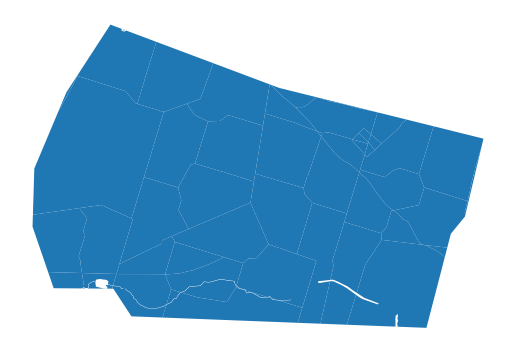

In [5]:
scenario_blocks = gpd.read_file('../data/prostor/blocks_price.geojson')
polygon_test = scenario_blocks.copy()

keep_cols = [
    'y_log_pred', 'price_pred', 'price_per_sotka', 'is_scn',
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]

polygon_test = (
    scenario_blocks
    .copy()
    .assign(
        land_use=lambda df: df['land_use'].astype(str).str.replace(r'^LandUse\.', '', regex=True)
    )[keep_cols]
)
polygon_test = polygon_test[polygon_test['is_scn'] == True].reset_index(drop=True)
polygon_test.plot().axis('off')
polygon_test

In [6]:
import pandas as pd
import geopandas as gpd

USES = ['residential','business','recreation','industrial','transport','special','agriculture']

# 1) подготовим карту оценок из base_gdf: среднее по типу
base_map = (
    base_gdf.assign(ip_type=base_gdf['ip_type'].str.lower())
            .loc[lambda d: d['ip_type'].isin(USES)]
            .groupby('ip_type', as_index=False)['ip_value'].mean()
            .rename(columns={'ip_value': 'ip_value_from_base'})
)

# 2) нормализуем polygon_test и удалим None/NaN типы
polygon_test = polygon_test.copy()
polygon_test['ip_type'] = polygon_test['land_use'].str.lower()
polygon_test = polygon_test[
    polygon_test['ip_type'].notna() & (polygon_test['ip_type'] != 'none')
]

# 3) джоин по типу и возьмем оценку из base_gdf
polygon_test = polygon_test.merge(base_map, on='ip_type', how='left')

# 4) если для типа нет оценки в base_gdf — ставим 0
polygon_test['ip_value'] = polygon_test['ip_value_from_base'].fillna(0)

# # 5) оставить только нужные колонки
# polygon_test = gpd.GeoDataFrame(
#     polygon_test[['ip_type', 'ip_value', 'geometry']].reset_index(drop=True),
#     crs=polygon_test.crs
# )

polygon_test



,y_log_pred,price_pred,price_per_sotka,is_scn,residential,business,recreation,industrial,transport,special,...,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,ip_type,ip_value_from_base,ip_value
0,18.221728,8.195883e+07,40493.546438,True,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.062008,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,"POLYGON ((388511.373 6644951.946, 388558.037 6...",agriculture,3.0,3.0
1,18.797440,1.457553e+08,72324.555126,True,0.000000,0.938081,0.0,0.0,0.000000,0.0,...,0.202340,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,"POLYGON ((388558.037 6645102.374, 388511.373 6...",business,2.0,2.0
2,18.188395,7.927197e+07,48141.693571,True,0.000000,0.000000,0.0,0.0,0.891381,0.0,...,0.151737,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,"POLYGON ((387957.434 6643444.937, 388007.492 6...",transport,4.0,4.0
3,19.331505,2.486372e+08,153886.457775,True,0.934862,0.000000,0.0,0.0,0.000000,0.0,...,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,"POLYGON ((388007.492 6643608.409, 387957.434 6...",residential,4.0,4.0
4,11.229530,7.532216e+04,150865.145895,True,0.132440,0.000000,0.0,0.0,0.000000,0.0,...,0.043463,0.046147,0.312842,0.941858,individual residential,122.644454,"POLYGON ((388000.75 6643199.606, 388001.306 66...",residential,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,13.136840,5.072911e+05,83575.819334,True,0.000000,1.000000,0.0,0.0,0.000000,0.0,...,0.335491,0.097449,0.000000,3.442739,low-rise non-residential,134.206771,"POLYGON ((390950.379 6643779.96, 390941.389 66...",business,2.0,2.0
63,2.399302,1.101548e+01,411.883468,True,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.061681,0.000000,0.000000,None,135.441874,"POLYGON ((391069.678 6644283.933, 391072.529 6...",agriculture,3.0,3.0
64,14.559295,2.103883e+06,48840.513520,True,0.000000,0.000000,0.0,0.0,0.910136,0.0,...,0.159849,0.095230,0.000000,1.678555,low-rise non-residential,122.979535,"POLYGON ((388222.552 6643218.262, 388215.418 6...",transport,4.0,4.0
65,10.987300,5.911855e+04,95927.689778,True,0.000000,1.000000,0.0,0.0,0.000000,0.0,...,0.218849,0.142625,0.000000,1.534440,low-rise non-residential,126.832893,"POLYGON ((388314.421 6645193.77, 388311.871 66...",business,2.0,2.0


In [7]:
benchmarks_demo = {
    "RESIDENTIAL": {
        "cost_build": 45_000,
        "price_sale": 90_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,
    },
    "BUSINESS": {
        "cost_build": 55_000,
        "rent_annual": 14_000,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 1300,
    },
    "RECREATION": {
        "cost_build": 20_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 2,
        "opex_rate": 1000,
    },
    "SPECIAL": {
        "cost_build": 35_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1500,
    },
    "INDUSTRIAL": {
        "cost_build": 38_000,
        "rent_annual": 9_800,
        "rent_years": 12,
        "construction_years": 2,
        "opex_rate": 700,
    },
    "AGRICULTURE": {
        "cost_build": 25_000,
        "rent_annual": 2_500,
        "rent_years": 15,
        "construction_years": 2,
        "opex_rate": 300,
    },
    "TRANSPORT": {
        "cost_build": 18_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [8]:
from urbanomy.methods.investment_potential import prepare_investment_input

polygon_input = prepare_investment_input(polygon_test)
polygon_input.head()


,geometry,land_use,price_pred,site_area,living_area,non_living_area,build_floor_area,share,price_per_sotka,ip_value
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",AGRICULTURE,8.195883e+07,202399.732193,0.000000,12550.416350,12550.416350,0.918180,40493.546438,3.0
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",BUSINESS,1.457553e+08,201529.493481,0.000000,40777.554163,40777.554163,0.938081,72324.555126,2.0
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",TRANSPORT,7.927197e+07,164663.859830,0.000000,24985.657278,24985.657278,0.891381,48141.693571,4.0
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",RESIDENTIAL,2.486372e+08,161571.832511,29356.894977,43211.816923,72568.711901,0.934862,153886.457775,4.0
4,"POLYGON ((388000.75 6643199.606, 388001.306 66...",RESIDENTIAL,7.532216e+04,49.926816,0.678865,1.491128,2.169993,0.132440,150865.145895,4.0


In [ ]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
gdf_out, summary = an.calculate_investment_metrics(polygon_input)
summary


,land_use,land_area,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,AGRICULTURE,"202,399.73","12,550.42","81,958,829.55","313,760,408.75","395,719,238.30","-226,616,469.30",0.00,0.92,NaN,0.00,3.00,21.36
1,BUSINESS,"201,529.49","40,777.55","145,755,309.61","2,242,765,478.95","2,388,520,788.56","225,964,705.95",0.14,4.81,12.87,45.55,2.00,26.09
2,TRANSPORT,"164,663.86","24,985.66","79,271,970.82","449,741,831.00","529,013,801.82","-56,054,975.93",0.10,3.83,NaN,0.00,4.00,42.73
3,RESIDENTIAL,"161,571.83","72,568.71","248,637,169.81","3,265,592,035.52","3,514,229,205.34","1,204,905,902.86",0.27,2.51,4.11,91.47,4.00,95.11
4,RESIDENTIAL,49.93,2.17,"75,322.16","97,649.70","172,971.87","-31,857.44",0.04,1.14,NaN,0.00,4.00,42.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,AGRICULTURE,2.67,NaN,11.02,NaN,11.02,"-27,509.99",0.03,1.64,NaN,0.00,3.00,21.36
64,TRANSPORT,"4,307.66",688.58,"2,103,882.71","12,394,358.77","14,498,241.48","-1,169,555.43",0.11,4.01,NaN,0.00,4.00,42.73
65,BUSINESS,61.63,13.49,"59,118.55","741,800.00","800,918.55","121,563.52",0.15,5.09,11.93,7.90,2.00,4.52
66,SPECIAL,175.85,60.89,"75,508.22","2,131,233.21","2,206,741.44","162,479.77",0.13,5.75,15.44,3.55,4.00,44.76


In [ ]:
# gdf_out.to_file('../data/prostor/blocks_investment.geojson', driver='GeoJSON')

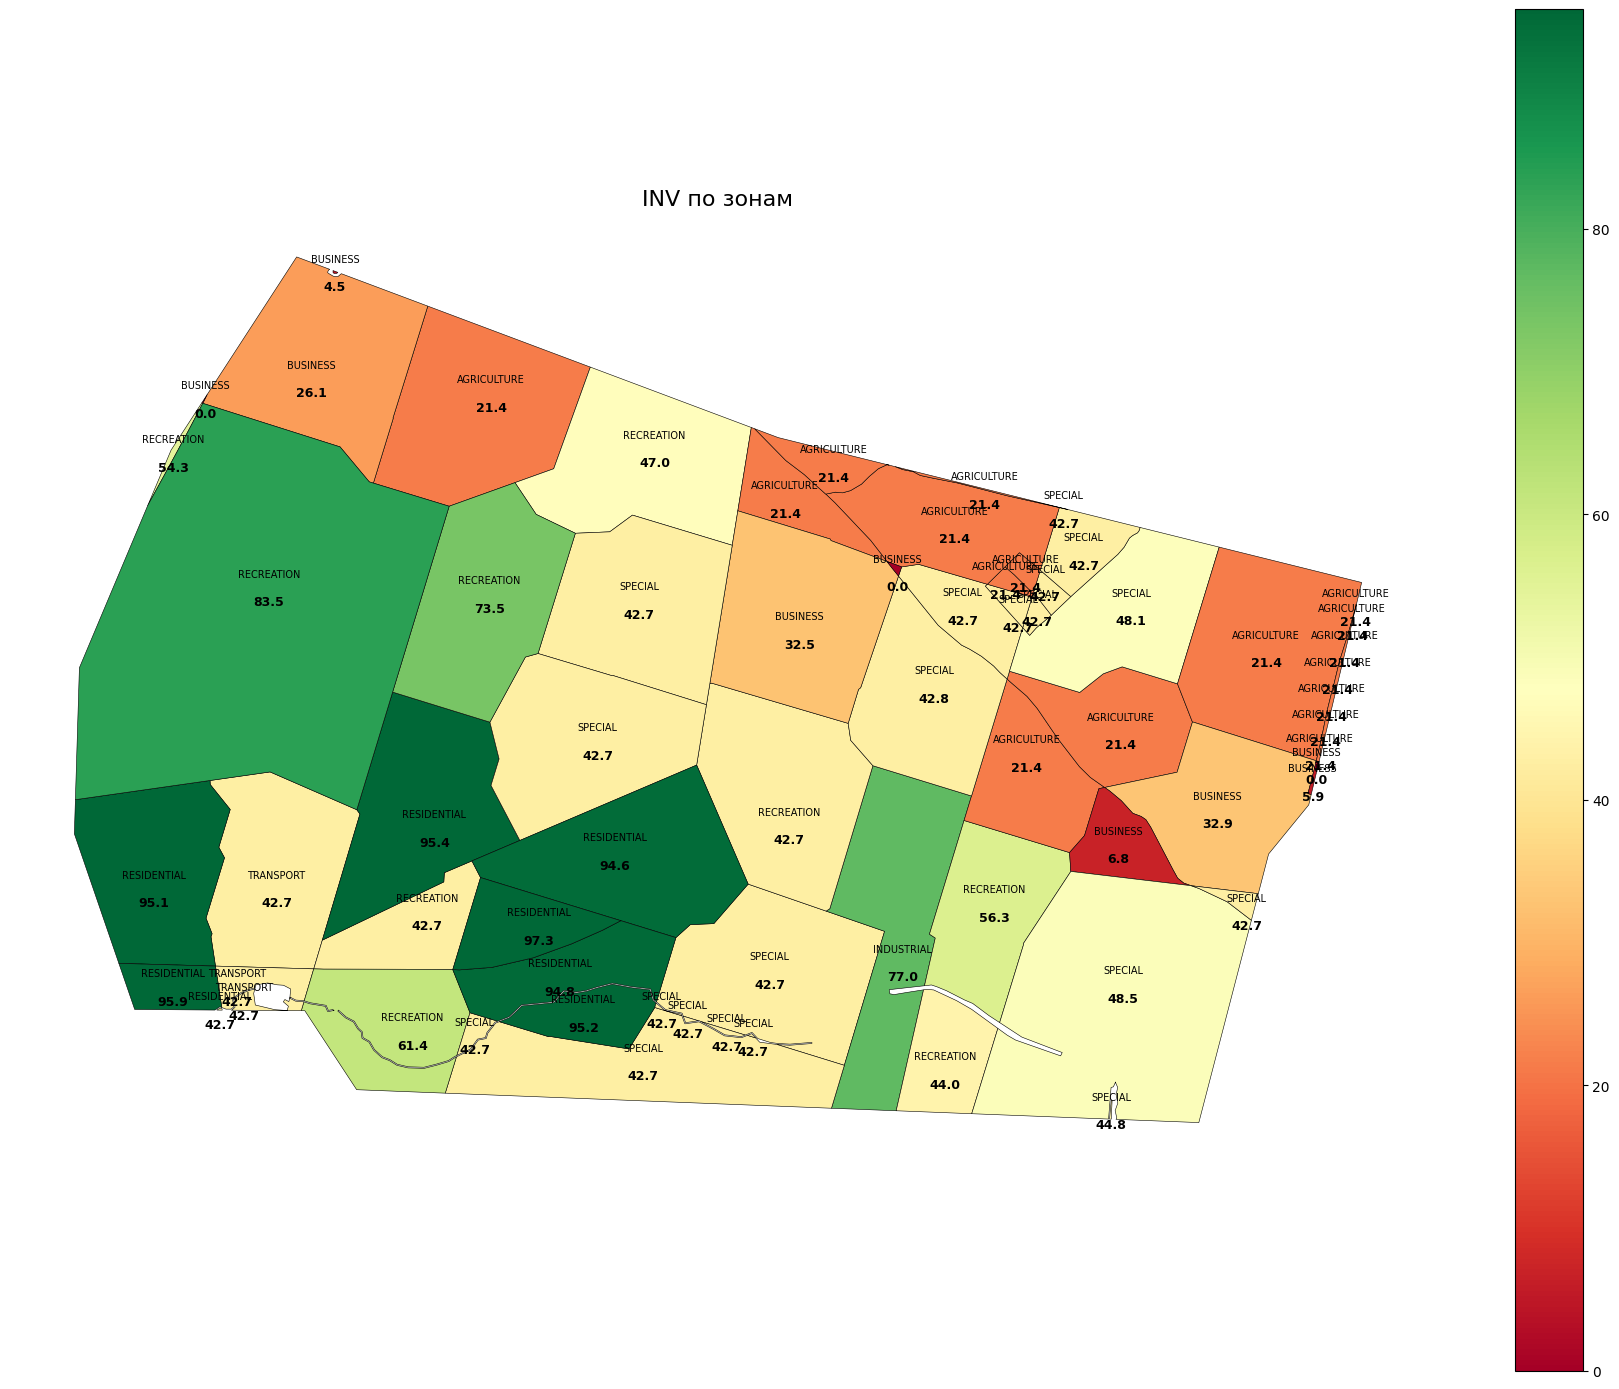

In [10]:
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy

plot_gdf = gdf_out.copy()
if plot_gdf.empty:
    raise ValueError("GeoDataFrame 'gdf_out' is empty; run calculate_investment_metrics first.")

fig, ax = plt.subplots(figsize=(18, 14))
vmin, vmax = plot_gdf['INV'].min(), plot_gdf['EI'].max()
plot_gdf.plot(column='INV', cmap='RdYlGn', vmin=vmin, vmax=vmax,
              edgecolor='black', linewidth=0.4, legend=True, ax=ax)

for _, row in plot_gdf.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(x, y, row['land_use'], ha='center', va='bottom', fontsize=7,
            color='black', transform=offset_copy(ax.transData, fig=fig, y=6, units='points'), zorder=3)
    ax.text(x, y, f"{row['INV']:.1f}", ha='center', va='top', fontsize=9, fontweight='bold',
            color='black', transform=offset_copy(ax.transData, fig=fig, y=-6, units='points'), zorder=3)

ax.set_title('INV по зонам', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()
